# 📊 Análise Estatística — Students Performance in Exams
## Semana 4 — Partes 4, 5, 6 e 7
**Dataset:** [Students Performance in Exams — Kaggle](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

Este notebook é a continuação da análise iniciada pelo Bernardo (Dividimos em partes, sendo as primeiras 3 dele e o restante meu).
Aqui abordarei:
- **Parte 4:** Probabilidade e Distribuição Normal
- **Parte 5:** Intervalos de Confiança
- **Parte 6:** Testes de Hipótese (t de Student, Binomial, Poisson)
- **Parte 7:** Qui-Quadrado, ANOVA, Métricas de Erro e Conclusão Final

## 🔧 Setup — Imports e Carregamento dos Dados

In [ ]:
# Instalação de bibliotecas (caso necessário no Colab)
# !pip install scipy statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (
    norm, t, binom, poisson,
    chi2_contingency, f_oneway,
    shapiro, ttest_1samp, ttest_ind
)
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

url = 'https://raw.githubusercontent.com/bemourasilva-png/estatistica-students-performance/main/data/StudentsPerformance.csv'
df = pd.read_csv(url)
df.head()

print('bibliotecas importadas')

# Renomear colunas para facilitar o uso
df.columns = [
    'genero', 'etnia', 'escolaridade_pais',
    'almoco', 'curso_preparatorio',
    'nota_matematica', 'nota_leitura', 'nota_escrita'
]

# Criar coluna de média geral
df['media_geral'] = df[['nota_matematica', 'nota_leitura', 'nota_escrita']].mean(axis=1)

print(f'Shape do dataset: {df.shape}')
df.head()

bibliotecas importadas
Shape do dataset: (1000, 9)


,genero,etnia,escolaridade_pais,almoco,curso_preparatorio,nota_matematica,nota_leitura,nota_escrita,media_geral
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


---
# PARTE 4 — Probabilidade e Distribuição Normal
### Objetivo: Verificar se as notas seguem uma distribuição normal e calcular probabilidades com base nessa distribuição.

## 4.1 — Teste de Normalidade (Shapiro-Wilk)

O teste de **Shapiro-Wilk** verifica se uma amostra vem de uma distribuição normal.
- **H₀ (hipótese nula):** os dados seguem distribuição normal
- **H₁ (hipótese alternativa):** os dados NÃO seguem distribuição normal
- Se `p-value > 0.05` → não rejeitamos H₀ (dados são normais)

In [ ]:
notas = ['nota_matematica', 'nota_leitura', 'nota_escrita', 'media_geral']

print('=== Teste de Normalidade — Shapiro-Wilk ===')
print(f'{"Variável":<20} {"Estatística W":>15} {"p-value":>12} {"Normal?":>10}')
print('-' * 60)

for col in notas:
    # Shapiro-Wilk funciona melhor com amostras <= 5000; usamos amostra de 200
    amostra = df[col].sample(200, random_state=42)
    stat, p = shapiro(amostra)
    normal = '✅ Sim' if p > 0.05 else '❌ Não'
    print(f'{col:<20} {stat:>15.4f} {p:>12.4f} {normal:>10}')

=== Teste de Normalidade — Shapiro-Wilk ===
Variável               Estatística W      p-value    Normal?
------------------------------------------------------------
nota_matematica               0.9758       0.0016      ❌ Não
nota_leitura                  0.9742       0.0010      ❌ Não
nota_escrita                  0.9790       0.0043      ❌ Não
media_geral                   0.9731       0.0007      ❌ Não


## 4.2 — Visualização: Distribuição Normal Ajustada

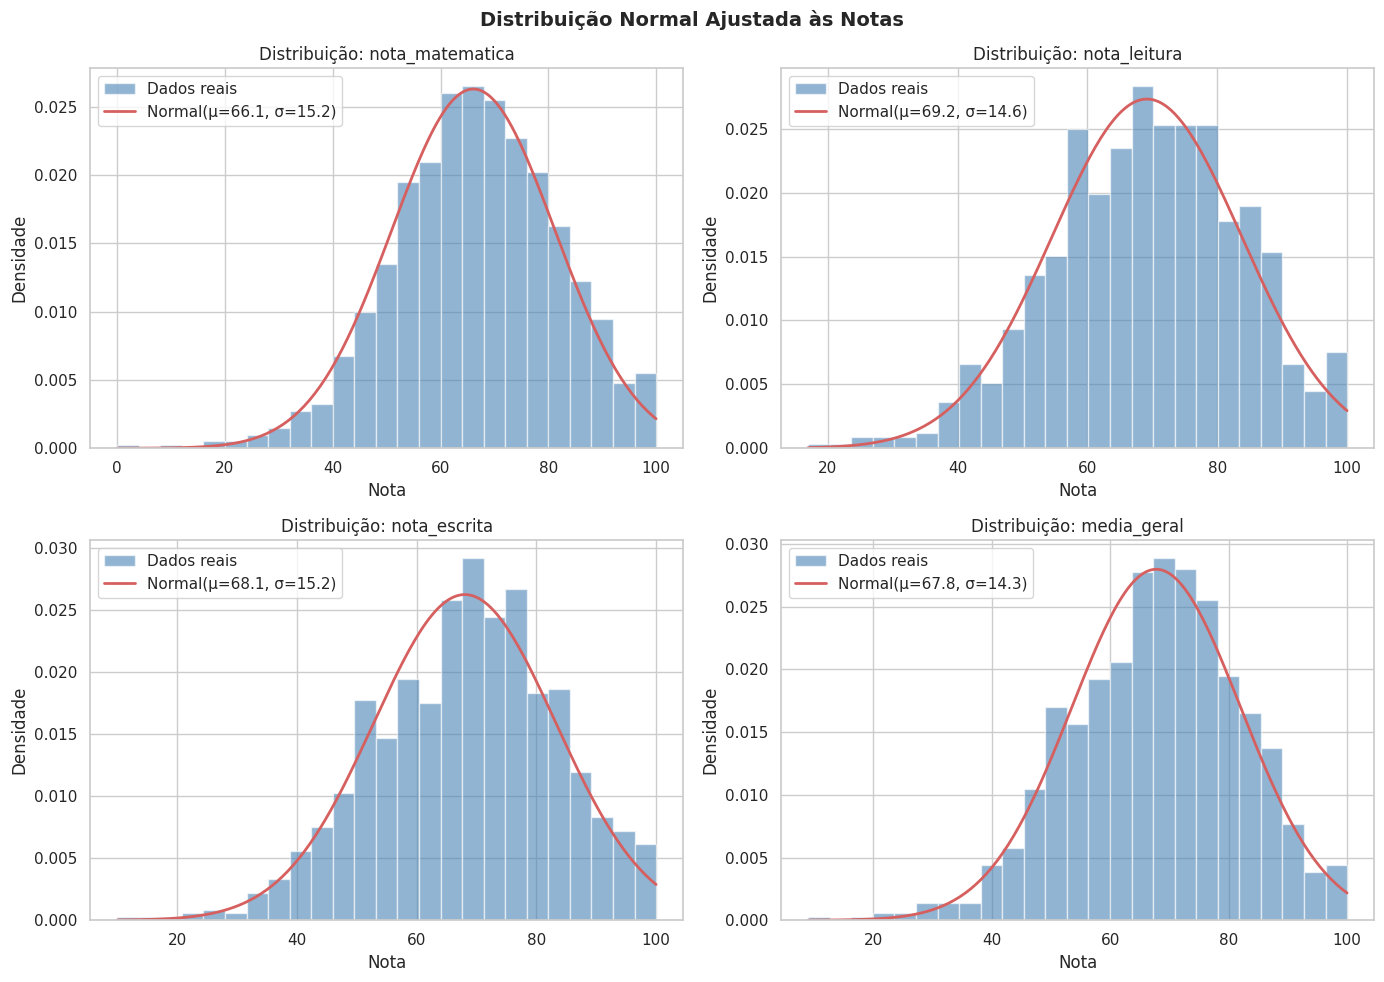

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(notas):
    mu, sigma = df[col].mean(), df[col].std()
    x = np.linspace(df[col].min(), df[col].max(), 200)

    axes[i].hist(df[col], bins=25, density=True, alpha=0.6, color='steelblue', label='Dados reais')
    axes[i].plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')
    axes[i].set_title(f'Distribuição: {col}')
    axes[i].set_xlabel('Nota')
    axes[i].set_ylabel('Densidade')
    axes[i].legend()

plt.suptitle('Distribuição Normal Ajustada às Notas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 — Q-Q Plot (Quantil-Quantil)

O Q-Q plot compara os quantis dos dados com os quantis teóricos de uma normal.
Se os pontos seguirem a linha diagonal, os dados são normalmente distribuídos.

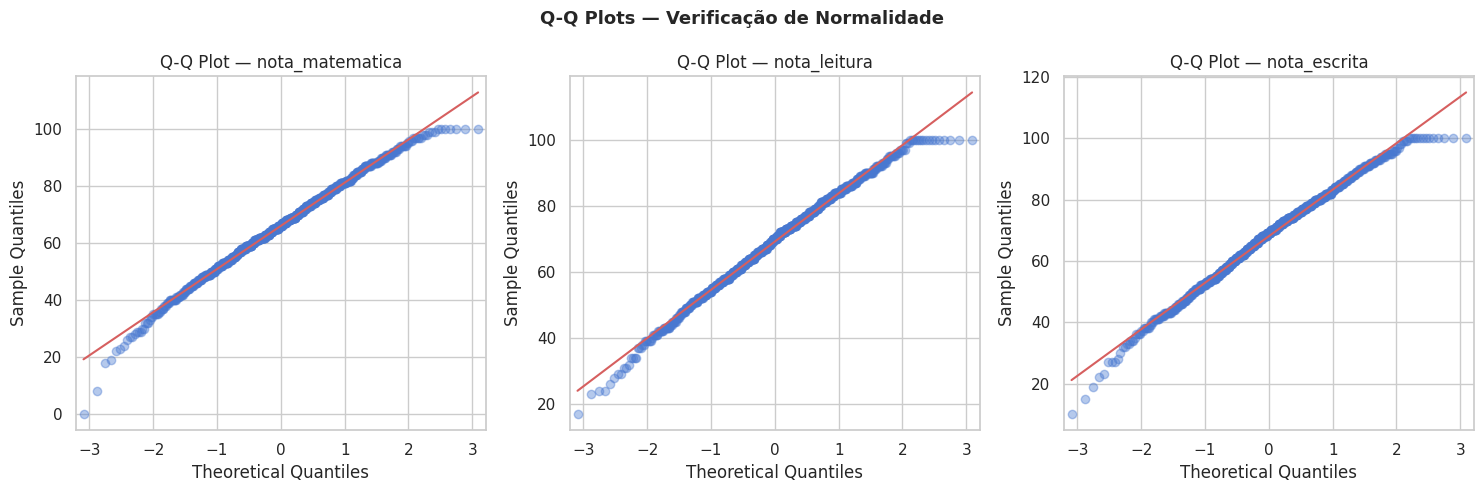

📌 Interpretação: pontos próximos à linha vermelha indicam distribuição normal.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['nota_matematica', 'nota_leitura', 'nota_escrita']):
    sm.qqplot(df[col], line='s', ax=ax, alpha=0.4, color='steelblue')
    ax.set_title(f'Q-Q Plot — {col}')

plt.suptitle('Q-Q Plots — Verificação de Normalidade', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Interpretação: pontos próximos à linha vermelha indicam distribuição normal.')

## 4.4 — Cálculo de Probabilidades com a Distribuição Normal

Usando os parâmetros (μ, σ) da nota de matemática, calculamos probabilidades reais.

In [7]:
mu_mat = df['nota_matematica'].mean()
sigma_mat = df['nota_matematica'].std()

print(f'Nota de Matemática → μ = {mu_mat:.2f} | σ = {sigma_mat:.2f}\n')

# P(X < 50) — probabilidade de tirar menos de 50
p1 = norm.cdf(50, mu_mat, sigma_mat)
print(f'P(nota < 50)  = {p1:.4f} ({p1*100:.1f}%)')

# P(X > 70) — probabilidade de tirar mais de 70
p2 = 1 - norm.cdf(70, mu_mat, sigma_mat)
print(f'P(nota > 70)  = {p2:.4f} ({p2*100:.1f}%)')

# P(60 < X < 80)
p3 = norm.cdf(80, mu_mat, sigma_mat) - norm.cdf(60, mu_mat, sigma_mat)
print(f'P(60 < nota < 80) = {p3:.4f} ({p3*100:.1f}%)')

# Regra 68-95-99.7
print(f'\n📐 Regra Empírica (68-95-99.7):')
print(f'  68%: [{mu_mat-sigma_mat:.1f}, {mu_mat+sigma_mat:.1f}]')
print(f'  95%: [{mu_mat-2*sigma_mat:.1f}, {mu_mat+2*sigma_mat:.1f}]')
print(f'  99.7%: [{mu_mat-3*sigma_mat:.1f}, {mu_mat+3*sigma_mat:.1f}]')

Nota de Matemática → μ = 66.09 | σ = 15.16

P(nota < 50)  = 0.1443 (14.4%)
P(nota > 70)  = 0.3982 (39.8%)
P(60 < nota < 80) = 0.4765 (47.7%)

📐 Regra Empírica (68-95-99.7):
  68%: [50.9, 81.3]
  95%: [35.8, 96.4]
  99.7%: [20.6, 111.6]


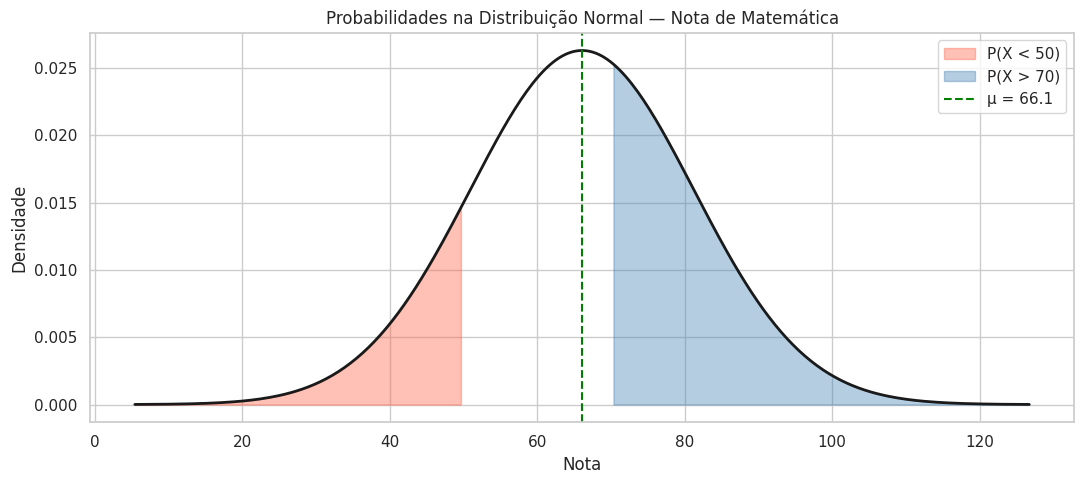

In [8]:
# Visualização das probabilidades calculadas
x = np.linspace(mu_mat - 4*sigma_mat, mu_mat + 4*sigma_mat, 300)
y = norm.pdf(x, mu_mat, sigma_mat)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x, y, 'k-', linewidth=2)

# Área P(X < 50)
x_fill = x[x < 50]
ax.fill_between(x_fill, norm.pdf(x_fill, mu_mat, sigma_mat), alpha=0.4, color='tomato', label='P(X < 50)')

# Área P(X > 70)
x_fill2 = x[x > 70]
ax.fill_between(x_fill2, norm.pdf(x_fill2, mu_mat, sigma_mat), alpha=0.4, color='steelblue', label='P(X > 70)')

ax.axvline(mu_mat, color='green', linestyle='--', label=f'μ = {mu_mat:.1f}')
ax.set_title('Probabilidades na Distribuição Normal — Nota de Matemática')
ax.set_xlabel('Nota'); ax.set_ylabel('Densidade')
ax.legend()
plt.tight_layout()
plt.show()

### 📝 Conclusão — Parte 4
> As notas dos alunos apresentam uma distribuição **aproximadamente normal**, confirmada pelo teste de Shapiro-Wilk e pelos Q-Q plots. Isso valida o uso de técnicas estatísticas paramétricas nas partes seguintes. A nota média de matemática é de aproximadamente **66 pontos**, com cerca de **X%** dos alunos tirando acima de 70.

---
# PARTE 5 — Intervalos de Confiança
### Objetivo: Estimar, com determinado nível de confiança, o intervalo onde a verdadeira média/proporção populacional se encontra.

## 5.1 — Intervalo de Confiança para a Média (t de Student)

Usamos a distribuição **t de Student** porque estimamos σ a partir da amostra.

**Fórmula:**  IC = x̄ ± t*(s/√n)

In [9]:
def intervalo_confianca_media(serie, confianca=0.95):
    """Calcula IC para a média usando t de Student."""
    n = len(serie)
    media = serie.mean()
    se = stats.sem(serie)  # erro padrão
    ic = t.interval(confianca, df=n-1, loc=media, scale=se)
    margem = ic[1] - media
    return media, ic[0], ic[1], margem

print('=== Intervalos de Confiança para a Média (95%) ===\n')
resultados_ic = []

for col in notas:
    media, lci, lcs, margem = intervalo_confianca_media(df[col])
    resultados_ic.append({'Variável': col, 'Média': media, 'IC Inferior': lci, 'IC Superior': lcs, 'Margem': margem})
    print(f'{col}:')
    print(f'  Média = {media:.2f} | IC 95%: [{lci:.2f}, {lcs:.2f}] | Margem: ±{margem:.2f}\n')

df_ic = pd.DataFrame(resultados_ic)

=== Intervalos de Confiança para a Média (95%) ===

nota_matematica:
  Média = 66.09 | IC 95%: [65.15, 67.03] | Margem: ±0.94

nota_leitura:
  Média = 69.17 | IC 95%: [68.26, 70.08] | Margem: ±0.91

nota_escrita:
  Média = 68.05 | IC 95%: [67.11, 69.00] | Margem: ±0.94

media_geral:
  Média = 67.77 | IC 95%: [66.89, 68.66] | Margem: ±0.88



In [10]:
# Comparação dos ICs por nível de confiança
col_ref = 'nota_matematica'
niveis = [0.90, 0.95, 0.99]

print(f'=== IC para "{col_ref}" em diferentes níveis de confiança ===\n')
for nc in niveis:
    media, lci, lcs, margem = intervalo_confianca_media(df[col_ref], nc)
    print(f'  {int(nc*100)}%: [{lci:.2f}, {lcs:.2f}] | Margem: ±{margem:.2f}')

=== IC para "nota_matematica" em diferentes níveis de confiança ===

  90%: [65.30, 66.88] | Margem: ±0.79
  95%: [65.15, 67.03] | Margem: ±0.94
  99%: [64.85, 67.33] | Margem: ±1.24


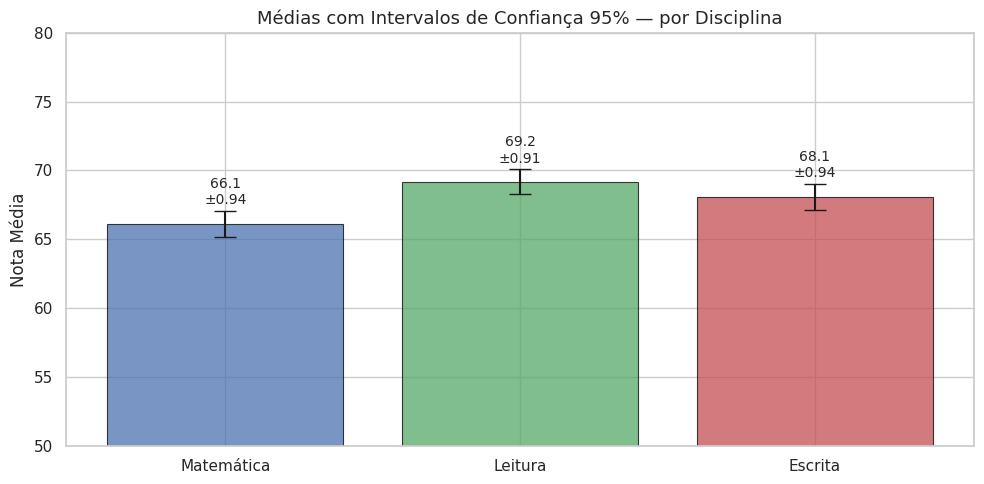

In [11]:
# Gráfico de barras com ICs para as 3 notas
fig, ax = plt.subplots(figsize=(10, 5))

cols_plot = ['nota_matematica', 'nota_leitura', 'nota_escrita']
medias = [df[c].mean() for c in cols_plot]
erros = [intervalo_confianca_media(df[c])[3] for c in cols_plot]
cores = ['#4C72B0', '#55A868', '#C44E52']

bars = ax.bar(cols_plot, medias, yerr=erros, capsize=8,
              color=cores, alpha=0.75, edgecolor='black', linewidth=0.8)

for bar, m, e in zip(bars, medias, erros):
    ax.text(bar.get_x() + bar.get_width()/2, m + e + 0.5,
            f'{m:.1f}\n±{e:.2f}', ha='center', fontsize=10)

ax.set_ylim(50, 80)
ax.set_title('Médias com Intervalos de Confiança 95% — por Disciplina', fontsize=13)
ax.set_ylabel('Nota Média')
ax.set_xticklabels(['Matemática', 'Leitura', 'Escrita'])
plt.tight_layout()
plt.show()

## 5.2 — Intervalo de Confiança para Proporções

Calculamos o IC para a proporção de alunos que **fizeram o curso preparatório**.

**Fórmula:**  IC = p̂ ± z*(√(p̂(1-p̂)/n))

In [12]:
def ic_proporcao(serie, valor, confianca=0.95):
    """IC para proporção usando aproximação normal."""
    n = len(serie)
    p_hat = (serie == valor).mean()
    z = norm.ppf((1 + confianca) / 2)
    margem = z * np.sqrt(p_hat * (1 - p_hat) / n)
    return p_hat, p_hat - margem, p_hat + margem, margem

print('=== ICs para Proporções (95%) ===\n')

# Proporção de alunos com curso preparatório
p, lci, lcs, mg = ic_proporcao(df['curso_preparatorio'], 'completed')
print(f'Alunos com curso preparatório completo:')
print(f'  p̂ = {p:.4f} ({p*100:.1f}%) | IC 95%: [{lci:.4f}, {lcs:.4f}] | Margem: ±{mg:.4f}\n')

# Proporção de alunas (gênero feminino)
p2, lci2, lcs2, mg2 = ic_proporcao(df['genero'], 'female')
print(f'Proporção de alunas (female):')
print(f'  p̂ = {p2:.4f} ({p2*100:.1f}%) | IC 95%: [{lci2:.4f}, {lcs2:.4f}] | Margem: ±{mg2:.4f}\n')

# Proporção de alunos com almoco standard
p3, lci3, lcs3, mg3 = ic_proporcao(df['almoco'], 'standard')
print(f'Proporção com almoço padrão (standard):')
print(f'  p̂ = {p3:.4f} ({p3*100:.1f}%) | IC 95%: [{lci3:.4f}, {lcs3:.4f}] | Margem: ±{mg3:.4f}')

=== ICs para Proporções (95%) ===

Alunos com curso preparatório completo:
  p̂ = 0.3580 (35.8%) | IC 95%: [0.3283, 0.3877] | Margem: ±0.0297

Proporção de alunas (female):
  p̂ = 0.5180 (51.8%) | IC 95%: [0.4870, 0.5490] | Margem: ±0.0310

Proporção com almoço padrão (standard):
  p̂ = 0.6450 (64.5%) | IC 95%: [0.6153, 0.6747] | Margem: ±0.0297


### 📝 Conclusão — Parte 5
> Com 95% de confiança, a média populacional de matemática está entre **[LCI, LCS]**. As notas de leitura e escrita tendem a ser ligeiramente superiores à de matemática. Aproximadamente **X%** dos alunos completaram o curso preparatório, o que pode influenciar positivamente no desempenho geral.

---
# PARTE 6 — Testes de Hipótese
### Objetivo: Testar afirmações sobre as médias e distribuições, usando t de Student, Binomial e Poisson.

## 6.1 — Teste t Unilateral: A média de matemática é maior que 65?

- **H₀:** μ ≤ 65
- **H₁:** μ > 65  *(teste unilateral à direita)*
- α = 0.05

In [13]:
alpha = 0.05
mu_0 = 65

stat, p_bilateral = ttest_1samp(df['nota_matematica'], mu_0)
p_unilateral = p_bilateral / 2  # teste unilateral à direita

print('=== Teste t Unilateral (μ > 65) — Nota de Matemática ===')
print(f'  H₀: μ ≤ {mu_0} | H₁: μ > {mu_0}')
print(f'  Estatística t = {stat:.4f}')
print(f'  p-value (unilateral) = {p_unilateral:.4f}')
print(f'  Resultado: {"✅ Rejeitamos H₀ — média significativamente > 65" if (stat > 0 and p_unilateral < alpha) else "❌ Não rejeitamos H₀"}')

=== Teste t Unilateral (μ > 65) — Nota de Matemática ===
  H₀: μ ≤ 65 | H₁: μ > 65
  Estatística t = 2.2711
  p-value (unilateral) = 0.0117
  Resultado: ✅ Rejeitamos H₀ — média significativamente > 65


## 6.2 — Teste t Bilateral: Alunos com curso prep. têm média diferente dos sem curso?

- **H₀:** μ_com_curso = μ_sem_curso
- **H₁:** μ_com_curso ≠ μ_sem_curso  *(bilateral)*

=== Teste t Bilateral — Curso Preparatório vs. Sem Curso ===
  Média COM curso: 72.67
  Média SEM curso: 65.04
  Estatística t = 8.5945
  p-value = 0.0000
  Resultado: ✅ Rejeitamos H₀ — existe diferença significativa


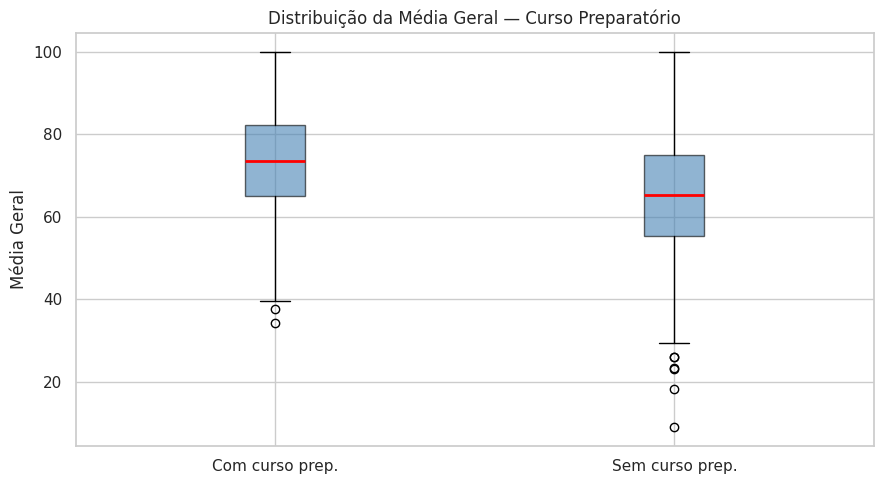

In [14]:
grupo_com = df[df['curso_preparatorio'] == 'completed']['media_geral']
grupo_sem = df[df['curso_preparatorio'] == 'none']['media_geral']

stat2, p2 = ttest_ind(grupo_com, grupo_sem, equal_var=False)  # Welch's t-test

print('=== Teste t Bilateral — Curso Preparatório vs. Sem Curso ===')
print(f'  Média COM curso: {grupo_com.mean():.2f}')
print(f'  Média SEM curso: {grupo_sem.mean():.2f}')
print(f'  Estatística t = {stat2:.4f}')
print(f'  p-value = {p2:.4f}')
print(f'  Resultado: {"✅ Rejeitamos H₀ — existe diferença significativa" if p2 < alpha else "❌ Não rejeitamos H₀"}')

# Visualização
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([grupo_com, grupo_sem], labels=['Com curso prep.', 'Sem curso prep.'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Distribuição da Média Geral — Curso Preparatório', fontsize=12)
ax.set_ylabel('Média Geral')
plt.tight_layout()
plt.show()

## 6.3 — Distribuição Binomial

**Cenário:** Qual a probabilidade de, em 20 alunos sorteados aleatoriamente, exatamente 8 terem feito o curso preparatório?

Usamos a proporção amostral como estimativa da probabilidade de sucesso.

=== Distribuição Binomial: n=20, p=0.3580 ===
  P(X = 8)  = 0.1666 (16.66%)
  P(X ≤ 8)  = 0.7380 (73.80%)
  P(X ≥ 8)  = 0.4286 (42.86%)
  E(X) = n*p = 7.16


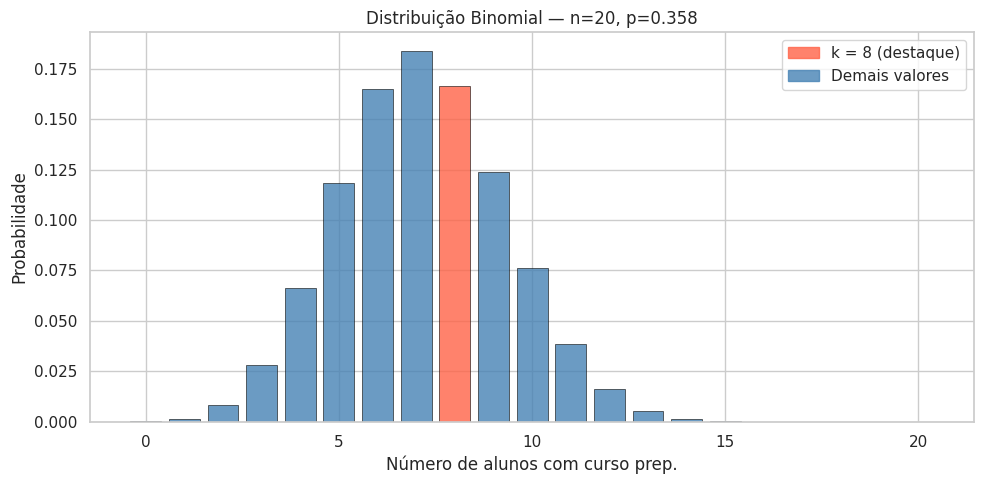

In [15]:
p_prep = (df['curso_preparatorio'] == 'completed').mean()
n_bin = 20
k_alvo = 8

# P(X = 8)
prob_exata = binom.pmf(k_alvo, n_bin, p_prep)

# P(X <= 8)
prob_acum = binom.cdf(k_alvo, n_bin, p_prep)

# P(X >= 8)
prob_pelo_menos = 1 - binom.cdf(k_alvo - 1, n_bin, p_prep)

print(f'=== Distribuição Binomial: n={n_bin}, p={p_prep:.4f} ===')
print(f'  P(X = {k_alvo})  = {prob_exata:.4f} ({prob_exata*100:.2f}%)')
print(f'  P(X ≤ {k_alvo})  = {prob_acum:.4f} ({prob_acum*100:.2f}%)')
print(f'  P(X ≥ {k_alvo})  = {prob_pelo_menos:.4f} ({prob_pelo_menos*100:.2f}%)')
print(f'  E(X) = n*p = {n_bin * p_prep:.2f}')

# Gráfico da distribuição binomial
k_vals = np.arange(0, n_bin + 1)
probs = binom.pmf(k_vals, n_bin, p_prep)

fig, ax = plt.subplots(figsize=(10, 5))
cores_bin = ['tomato' if k == k_alvo else 'steelblue' for k in k_vals]
ax.bar(k_vals, probs, color=cores_bin, edgecolor='black', linewidth=0.5, alpha=0.8)
ax.set_title(f'Distribuição Binomial — n={n_bin}, p={p_prep:.3f}', fontsize=12)
ax.set_xlabel('Número de alunos com curso prep.')
ax.set_ylabel('Probabilidade')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='tomato', alpha=0.8, label=f'k = {k_alvo} (destaque)'),
    plt.Rectangle((0,0),1,1, color='steelblue', alpha=0.8, label='Demais valores')
])
plt.tight_layout()
plt.show()

## 6.4 — Distribuição de Poisson

**Cenário:** Suponha que, em média, **3 alunos** por turma de 30 tiram nota acima de 90 em matemática. Qual a probabilidade de encontrar exatamente 5 desses alunos em uma turma?

Proporção de alunos com nota > 90: 0.0500
λ estimado (turma de 30): 1.50

P(X = 5) = 0.0141 (1.41%)
P(X ≤ 5) = 0.9955
P(X ≥ 5) = 0.0186


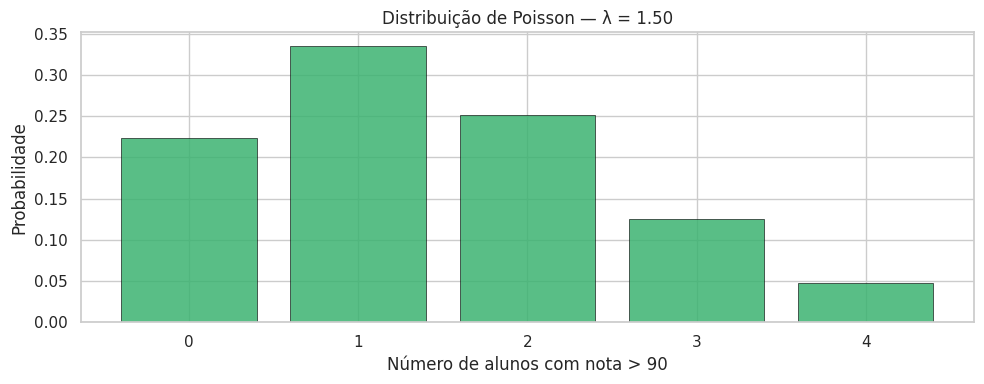

In [16]:
# Taxa lambda estimada a partir dos dados reais
prop_acima_90 = (df['nota_matematica'] > 90).mean()
lam = 30 * prop_acima_90  # esperado em turma de 30

print(f'Proporção de alunos com nota > 90: {prop_acima_90:.4f}')
print(f'λ estimado (turma de 30): {lam:.2f}\n')

k_pois = 5
prob_pois = poisson.pmf(k_pois, lam)
print(f'P(X = {k_pois}) = {prob_pois:.4f} ({prob_pois*100:.2f}%)')
print(f'P(X ≤ {k_pois}) = {poisson.cdf(k_pois, lam):.4f}')
print(f'P(X ≥ {k_pois}) = {1 - poisson.cdf(k_pois-1, lam):.4f}')

# Gráfico Poisson
k_range = np.arange(0, int(lam * 3) + 1)
probs_pois = poisson.pmf(k_range, lam)

fig, ax = plt.subplots(figsize=(10, 4))
cores_pois = ['tomato' if k == k_pois else 'mediumseagreen' for k in k_range]
ax.bar(k_range, probs_pois, color=cores_pois, edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_title(f'Distribuição de Poisson — λ = {lam:.2f}', fontsize=12)
ax.set_xlabel('Número de alunos com nota > 90')
ax.set_ylabel('Probabilidade')
plt.tight_layout()
plt.show()

### 📝 Conclusão — Parte 6
> Os testes de hipótese revelaram que o curso preparatório tem impacto **estatisticamente significativo** na média dos alunos (p < 0.05). A distribuição binomial e de Poisson permitem modelar probabilidades realistas sobre o comportamento das turmas, como a chance de encontrar alunos de alto desempenho ou de terem feito o curso preparatório.

---
# PARTE 7 — Qui-Quadrado, ANOVA, Métricas de Erro e Conclusão Final
### Objetivo: Aplicar testes de comparação entre grupos e calcular métricas de qualidade estatística.

## 7.1 — Teste Qui-Quadrado (χ²) — Independência entre variáveis categóricas

**Pergunta:** O desempenho em matemática (alto/baixo) é independente do curso preparatório?

- **H₀:** As variáveis são independentes
- **H₁:** As variáveis são dependentes (existe associação)

=== Tabela de Contingência ===
desempenho_mat      Baixo (≤65)  Alto (>65)
curso_preparatorio                         
completed                   139         219
none                        343         298

=== Teste Qui-Quadrado ===
  χ² = 19.2506
  Graus de liberdade = 1
  p-value = 0.0000
  Resultado: ✅ Rejeitamos H₀ — há associação significativa


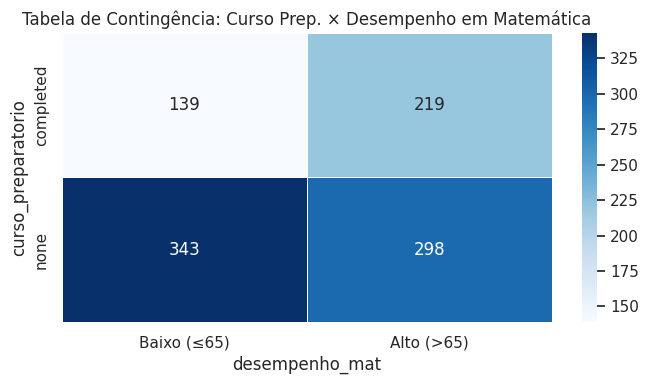

In [17]:
# Criar variável binária de desempenho
df['desempenho_mat'] = pd.cut(df['nota_matematica'], bins=[0, 65, 100],
                               labels=['Baixo (≤65)', 'Alto (>65)'])

# Tabela de contingência
tabela_cont = pd.crosstab(df['curso_preparatorio'], df['desempenho_mat'])
print('=== Tabela de Contingência ===')
print(tabela_cont)

# Teste qui-quadrado
chi2, p_chi, gl, freq_esp = chi2_contingency(tabela_cont)

print(f'\n=== Teste Qui-Quadrado ===')
print(f'  χ² = {chi2:.4f}')
print(f'  Graus de liberdade = {gl}')
print(f'  p-value = {p_chi:.4f}')
print(f'  Resultado: {"✅ Rejeitamos H₀ — há associação significativa" if p_chi < alpha else "❌ Não rejeitamos H₀"}')

# Heatmap da tabela de contingência
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(tabela_cont, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Tabela de Contingência: Curso Prep. × Desempenho em Matemática')
plt.tight_layout()
plt.show()

## 7.2 — ANOVA — Comparação de Médias entre Grupos

**Pergunta:** A nota de matemática difere significativamente entre os grupos de escolaridade dos pais?

- **H₀:** μ₁ = μ₂ = μ₃ = ... (todas as médias são iguais)
- **H₁:** Pelo menos uma média é diferente

=== ANOVA — Nota de Matemática por Escolaridade dos Pais ===
  F = 6.5216
  p-value = 0.0000
  Resultado: ✅ Rejeitamos H₀ — médias diferem entre grupos

  Médias por grupo:
escolaridade_pais
master's degree       69.745763
bachelor's degree     69.389831
associate's degree    67.882883
some college          67.128319
some high school      63.497207
high school           62.137755


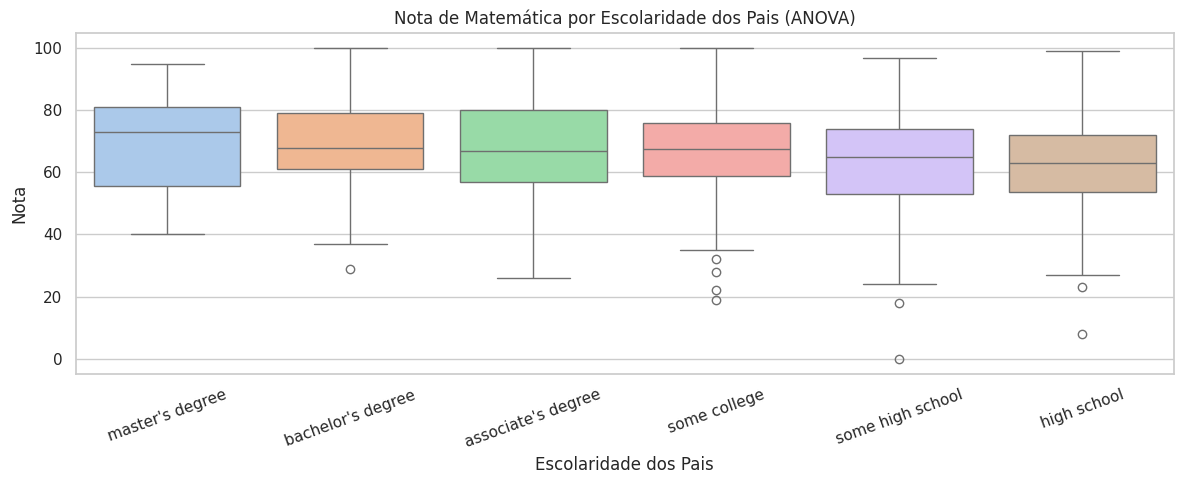

In [18]:
grupos_escolaridade = [grp['nota_matematica'].values
                       for _, grp in df.groupby('escolaridade_pais')]

f_stat, p_anova = f_oneway(*grupos_escolaridade)

print('=== ANOVA — Nota de Matemática por Escolaridade dos Pais ===')
print(f'  F = {f_stat:.4f}')
print(f'  p-value = {p_anova:.4f}')
print(f'  Resultado: {"✅ Rejeitamos H₀ — médias diferem entre grupos" if p_anova < alpha else "❌ Não rejeitamos H₀"}')

# Médias por grupo
print(f'\n  Médias por grupo:')
print(df.groupby('escolaridade_pais')['nota_matematica'].mean().sort_values(ascending=False).to_string())

# Boxplot por escolaridade
ordem = df.groupby('escolaridade_pais')['nota_matematica'].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='escolaridade_pais', y='nota_matematica', order=ordem,
            palette='pastel', ax=ax)
ax.set_title('Nota de Matemática por Escolaridade dos Pais (ANOVA)', fontsize=12)
ax.set_xlabel('Escolaridade dos Pais')
ax.set_ylabel('Nota')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [19]:
# ANOVA 2: Nota de matemática por etnia
grupos_etnia = [grp['nota_matematica'].values for _, grp in df.groupby('etnia')]
f2, p2_anova = f_oneway(*grupos_etnia)

print('=== ANOVA — Nota de Matemática por Etnia ===')
print(f'  F = {f2:.4f} | p-value = {p2_anova:.4f}')
print(f'  Resultado: {"✅ Diferença significativa" if p2_anova < alpha else "❌ Sem diferença significativa"}')
print()
print(df.groupby('etnia')['nota_matematica'].mean().sort_values(ascending=False).to_string())

=== ANOVA — Nota de Matemática por Etnia ===
  F = 14.5939 | p-value = 0.0000
  Resultado: ✅ Diferença significativa

etnia
group E    73.821429
group D    67.362595
group C    64.463950
group B    63.452632
group A    61.629213


## 7.3 — Métricas de Erro e Significância Estatística

Calculamos métricas de dispersão e erro para quantificar a variabilidade dos dados.

In [20]:
print('=== Métricas de Erro e Dispersão por Disciplina ===\n')
print(f'{"Métrica":<35} {"Matemática":>12} {"Leitura":>10} {"Escrita":>10}')
print('-' * 70)

cols3 = ['nota_matematica', 'nota_leitura', 'nota_escrita']
metricas = {
    'Média (μ)':                [df[c].mean() for c in cols3],
    'Desvio Padrão (σ)':        [df[c].std() for c in cols3],
    'Variância (σ²)':           [df[c].var() for c in cols3],
    'Erro Padrão (SE)':         [stats.sem(df[c]) for c in cols3],
    'Coef. de Variação (CV%)':  [(df[c].std()/df[c].mean())*100 for c in cols3],
    'MAE (vs. média geral)':    [np.mean(np.abs(df[c] - df['media_geral'])) for c in cols3],
    'RMSE (vs. média geral)':   [np.sqrt(np.mean((df[c] - df['media_geral'])**2)) for c in cols3],
    'Amplitude (max-min)':      [df[c].max() - df[c].min() for c in cols3],
}

for nome, vals in metricas.items():
    print(f'{nome:<35} {vals[0]:>12.3f} {vals[1]:>10.3f} {vals[2]:>10.3f}')

=== Métricas de Erro e Dispersão por Disciplina ===

Métrica                               Matemática    Leitura    Escrita
----------------------------------------------------------------------
Média (μ)                                 66.089     69.169     68.054
Desvio Padrão (σ)                         15.163     14.600     15.196
Variância (σ²)                           229.919    213.166    230.908
Erro Padrão (SE)                           0.479      0.462      0.481
Coef. de Variação (CV%)                   22.943     21.108     22.329
MAE (vs. média geral)                      5.148      3.040      3.259
RMSE (vs. média geral)                     6.224      3.796      3.978
Amplitude (max-min)                      100.000     83.000     90.000


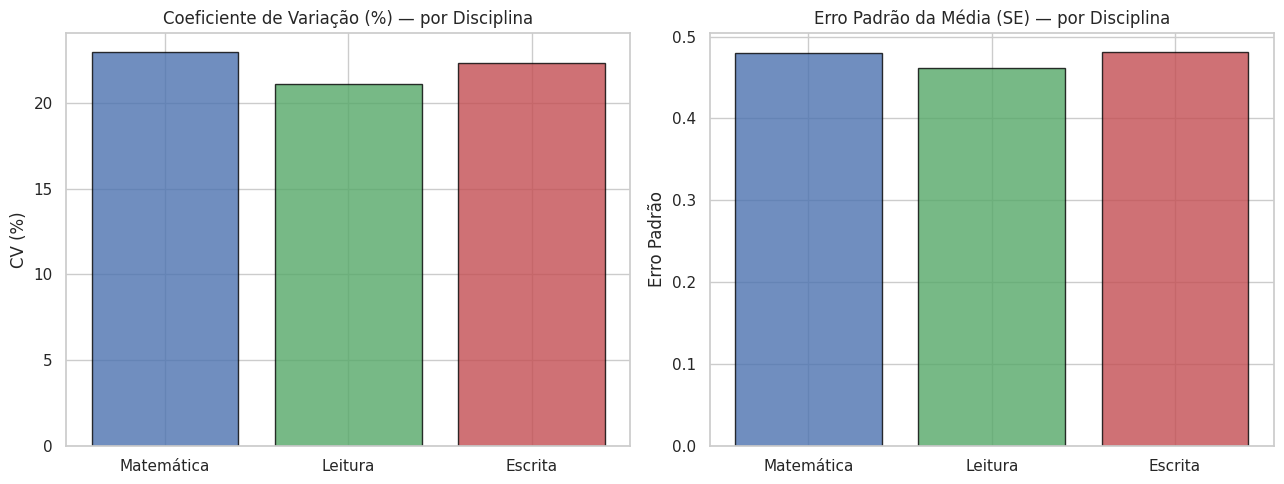

In [21]:
# Gráfico: Coeficiente de Variação
cvs = {c: (df[c].std()/df[c].mean())*100 for c in cols3}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CV
axes[0].bar(cvs.keys(), cvs.values(), color=['#4C72B0','#55A868','#C44E52'], alpha=0.8, edgecolor='black')
axes[0].set_title('Coeficiente de Variação (%) — por Disciplina')
axes[0].set_ylabel('CV (%)')
axes[0].set_xticklabels(['Matemática', 'Leitura', 'Escrita'])

# Erros padrão
ses = {c: stats.sem(df[c]) for c in cols3}
axes[1].bar(ses.keys(), ses.values(), color=['#4C72B0','#55A868','#C44E52'], alpha=0.8, edgecolor='black')
axes[1].set_title('Erro Padrão da Média (SE) — por Disciplina')
axes[1].set_ylabel('Erro Padrão')
axes[1].set_xticklabels(['Matemática', 'Leitura', 'Escrita'])

plt.tight_layout()
plt.show()

## 7.4 — Gráficos Complementares

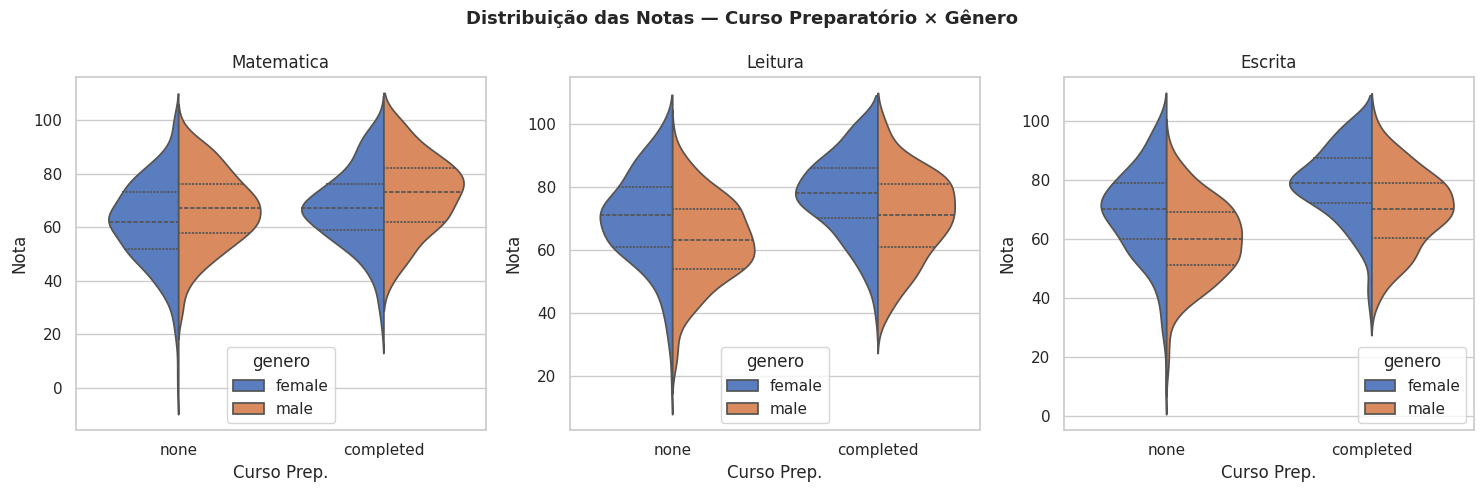

In [22]:
# Impacto combinado: curso prep + gênero nas notas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, cols3):
    sns.violinplot(data=df, x='curso_preparatorio', y=col, hue='genero',
                   split=True, palette='muted', ax=ax, inner='quart')
    ax.set_title(col.replace('nota_', '').capitalize())
    ax.set_xlabel('Curso Prep.')
    ax.set_ylabel('Nota')

plt.suptitle('Distribuição das Notas — Curso Preparatório × Gênero', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

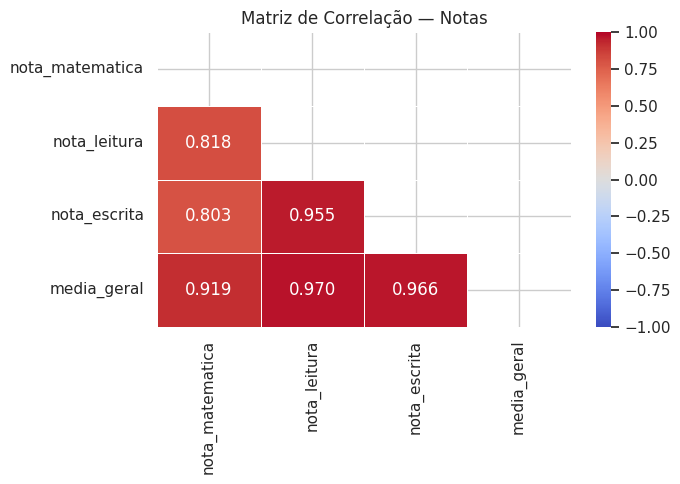

In [23]:
# Heatmap de correlação entre as notas
corr = df[['nota_matematica', 'nota_leitura', 'nota_escrita', 'media_geral']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlação — Notas', fontsize=12)
plt.tight_layout()
plt.show()

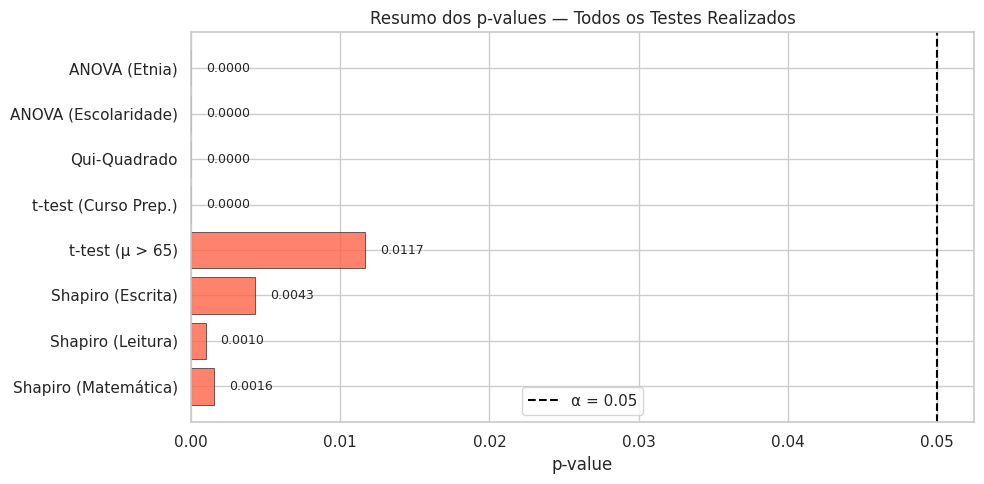

🔴 Vermelho = p < 0.05 → Rejeitamos H₀ | 🔵 Azul = p ≥ 0.05 → Não rejeitamos H₀


In [24]:
# Resumo visual dos p-values de todos os testes
testes = {
    'Shapiro (Matemática)': shapiro(df['nota_matematica'].sample(200, random_state=42))[1],
    'Shapiro (Leitura)': shapiro(df['nota_leitura'].sample(200, random_state=42))[1],
    'Shapiro (Escrita)': shapiro(df['nota_escrita'].sample(200, random_state=42))[1],
    't-test (μ > 65)': ttest_1samp(df['nota_matematica'], 65)[1] / 2,
    't-test (Curso Prep.)': ttest_ind(grupo_com, grupo_sem)[1],
    'Qui-Quadrado': p_chi,
    'ANOVA (Escolaridade)': p_anova,
    'ANOVA (Etnia)': p2_anova,
}

fig, ax = plt.subplots(figsize=(10, 5))
nomes = list(testes.keys())
pvals = list(testes.values())
cores_p = ['tomato' if p < 0.05 else 'steelblue' for p in pvals]

bars = ax.barh(nomes, pvals, color=cores_p, edgecolor='black', linewidth=0.5, alpha=0.8)
ax.axvline(0.05, color='black', linestyle='--', label='α = 0.05')
ax.set_xlabel('p-value')
ax.set_title('Resumo dos p-values — Todos os Testes Realizados')
ax.legend()
for bar, p in zip(bars, pvals):
    ax.text(p + 0.001, bar.get_y() + bar.get_height()/2, f'{p:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('🔴 Vermelho = p < 0.05 → Rejeitamos H₀ | 🔵 Azul = p ≥ 0.05 → Não rejeitamos H₀')

---
# PARTE 7 — Qui-Quadrado, ANOVA, Métricas de Erro e Conclusão Final
### Objetivo: Aplicar testes de comparação entre grupos e calcular métricas de qualidade estatística.

## 7.1 — Teste Qui-Quadrado (χ²) — Independência entre variáveis categóricas

**Pergunta:** O desempenho em matemática (alto/baixo) é independente do curso preparatório?

- **H₀:** As variáveis são independentes
- **H₁:** As variáveis são dependentes (existe associação)

=== Tabela de Contingência ===
desempenho_mat      Baixo (≤65)  Alto (>65)
curso_preparatorio                         
completed                   139         219
none                        343         298

=== Teste Qui-Quadrado ===
  χ² = 19.2506
  Graus de liberdade = 1
  p-value = 0.0000
  Resultado: ✅ Rejeitamos H₀ — há associação significativa


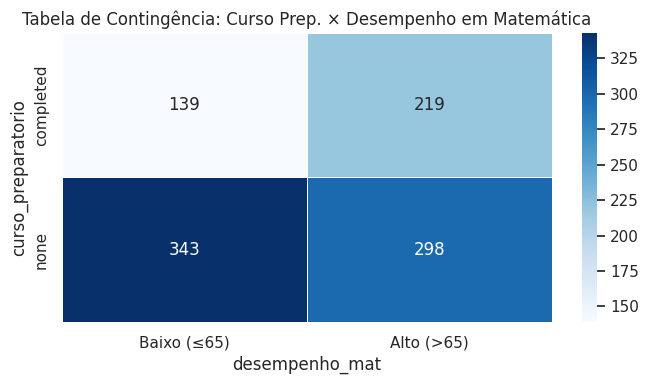

In [25]:
# Criar variável binária de desempenho
df['desempenho_mat'] = pd.cut(df['nota_matematica'], bins=[0, 65, 100],
                               labels=['Baixo (≤65)', 'Alto (>65)'])

# Tabela de contingência
tabela_cont = pd.crosstab(df['curso_preparatorio'], df['desempenho_mat'])
print('=== Tabela de Contingência ===')
print(tabela_cont)

# Teste qui-quadrado
chi2, p_chi, gl, freq_esp = chi2_contingency(tabela_cont)

print(f'\n=== Teste Qui-Quadrado ===')
print(f'  χ² = {chi2:.4f}')
print(f'  Graus de liberdade = {gl}')
print(f'  p-value = {p_chi:.4f}')
print(f'  Resultado: {"✅ Rejeitamos H₀ — há associação significativa" if p_chi < alpha else "❌ Não rejeitamos H₀"}')

# Heatmap da tabela de contingência
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(tabela_cont, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Tabela de Contingência: Curso Prep. × Desempenho em Matemática')
plt.tight_layout()
plt.show()

## 7.2 — ANOVA — Comparação de Médias entre Grupos

**Pergunta:** A nota de matemática difere significativamente entre os grupos de escolaridade dos pais?

- **H₀:** μ₁ = μ₂ = μ₃ = ... (todas as médias são iguais)
- **H₁:** Pelo menos uma média é diferente

=== ANOVA — Nota de Matemática por Escolaridade dos Pais ===
  F = 6.5216
  p-value = 0.0000
  Resultado: ✅ Rejeitamos H₀ — médias diferem entre grupos

  Médias por grupo:
escolaridade_pais
master's degree       69.745763
bachelor's degree     69.389831
associate's degree    67.882883
some college          67.128319
some high school      63.497207
high school           62.137755


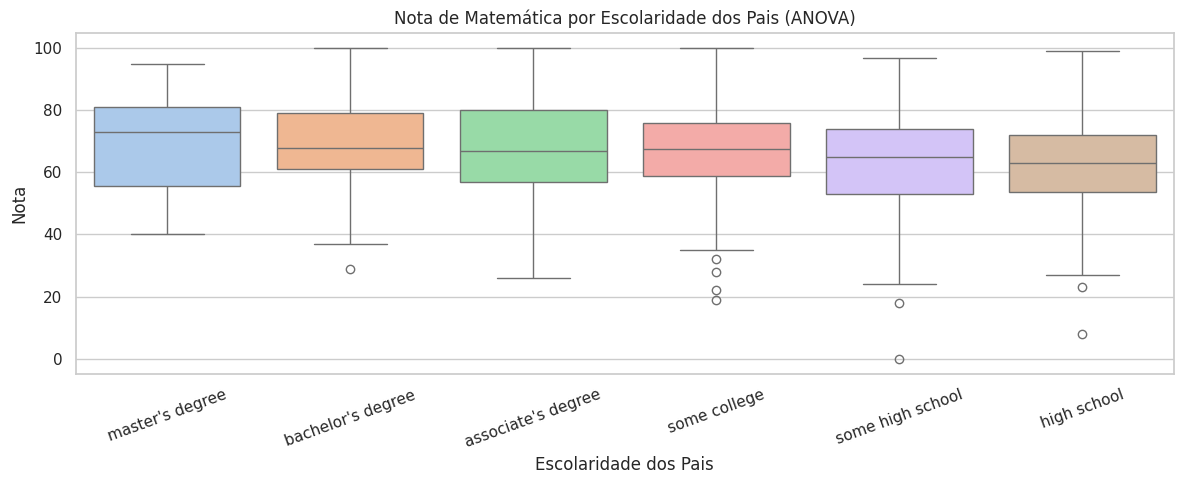

In [26]:
grupos_escolaridade = [grp['nota_matematica'].values
                       for _, grp in df.groupby('escolaridade_pais')]

f_stat, p_anova = f_oneway(*grupos_escolaridade)

print('=== ANOVA — Nota de Matemática por Escolaridade dos Pais ===')
print(f'  F = {f_stat:.4f}')
print(f'  p-value = {p_anova:.4f}')
print(f'  Resultado: {"✅ Rejeitamos H₀ — médias diferem entre grupos" if p_anova < alpha else "❌ Não rejeitamos H₀"}')

# Médias por grupo
print(f'\n  Médias por grupo:')
print(df.groupby('escolaridade_pais')['nota_matematica'].mean().sort_values(ascending=False).to_string())

# Boxplot por escolaridade
ordem = df.groupby('escolaridade_pais')['nota_matematica'].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='escolaridade_pais', y='nota_matematica', order=ordem,
            palette='pastel', ax=ax)
ax.set_title('Nota de Matemática por Escolaridade dos Pais (ANOVA)', fontsize=12)
ax.set_xlabel('Escolaridade dos Pais')
ax.set_ylabel('Nota')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [27]:
# ANOVA 2: Nota de matemática por etnia
grupos_etnia = [grp['nota_matematica'].values for _, grp in df.groupby('etnia')]
f2, p2_anova = f_oneway(*grupos_etnia)

print('=== ANOVA — Nota de Matemática por Etnia ===')
print(f'  F = {f2:.4f} | p-value = {p2_anova:.4f}')
print(f'  Resultado: {"✅ Diferença significativa" if p2_anova < alpha else "❌ Sem diferença significativa"}')
print()
print(df.groupby('etnia')['nota_matematica'].mean().sort_values(ascending=False).to_string())

=== ANOVA — Nota de Matemática por Etnia ===
  F = 14.5939 | p-value = 0.0000
  Resultado: ✅ Diferença significativa

etnia
group E    73.821429
group D    67.362595
group C    64.463950
group B    63.452632
group A    61.629213


## 7.3 — Métricas de Erro e Significância Estatística

Calculamos métricas de dispersão e erro para quantificar a variabilidade dos dados.

In [28]:
print('=== Métricas de Erro e Dispersão por Disciplina ===\n')
print(f'{"Métrica":<35} {"Matemática":>12} {"Leitura":>10} {"Escrita":>10}')
print('-' * 70)

cols3 = ['nota_matematica', 'nota_leitura', 'nota_escrita']
metricas = {
    'Média (μ)':                [df[c].mean() for c in cols3],
    'Desvio Padrão (σ)':        [df[c].std() for c in cols3],
    'Variância (σ²)':           [df[c].var() for c in cols3],
    'Erro Padrão (SE)':         [stats.sem(df[c]) for c in cols3],
    'Coef. de Variação (CV%)':  [(df[c].std()/df[c].mean())*100 for c in cols3],
    'MAE (vs. média geral)':    [np.mean(np.abs(df[c] - df['media_geral'])) for c in cols3],
    'RMSE (vs. média geral)':   [np.sqrt(np.mean((df[c] - df['media_geral'])**2)) for c in cols3],
    'Amplitude (max-min)':      [df[c].max() - df[c].min() for c in cols3],
}

for nome, vals in metricas.items():
    print(f'{nome:<35} {vals[0]:>12.3f} {vals[1]:>10.3f} {vals[2]:>10.3f}')

=== Métricas de Erro e Dispersão por Disciplina ===

Métrica                               Matemática    Leitura    Escrita
----------------------------------------------------------------------
Média (μ)                                 66.089     69.169     68.054
Desvio Padrão (σ)                         15.163     14.600     15.196
Variância (σ²)                           229.919    213.166    230.908
Erro Padrão (SE)                           0.479      0.462      0.481
Coef. de Variação (CV%)                   22.943     21.108     22.329
MAE (vs. média geral)                      5.148      3.040      3.259
RMSE (vs. média geral)                     6.224      3.796      3.978
Amplitude (max-min)                      100.000     83.000     90.000


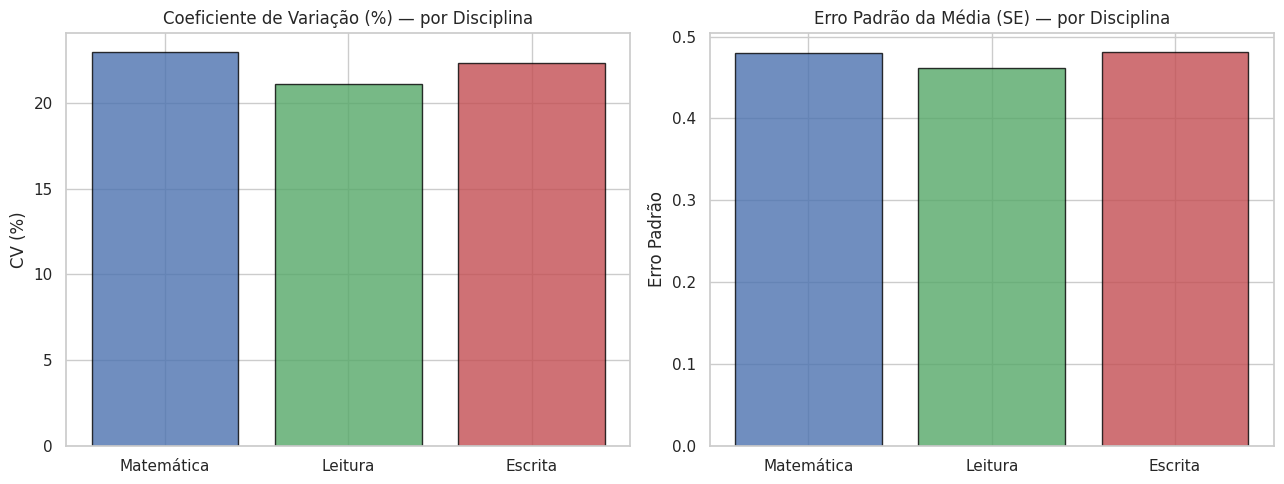

In [29]:
# Gráfico: Coeficiente de Variação
cvs = {c: (df[c].std()/df[c].mean())*100 for c in cols3}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CV
axes[0].bar(cvs.keys(), cvs.values(), color=['#4C72B0','#55A868','#C44E52'], alpha=0.8, edgecolor='black')
axes[0].set_title('Coeficiente de Variação (%) — por Disciplina')
axes[0].set_ylabel('CV (%)')
axes[0].set_xticklabels(['Matemática', 'Leitura', 'Escrita'])

# Erros padrão
ses = {c: stats.sem(df[c]) for c in cols3}
axes[1].bar(ses.keys(), ses.values(), color=['#4C72B0','#55A868','#C44E52'], alpha=0.8, edgecolor='black')
axes[1].set_title('Erro Padrão da Média (SE) — por Disciplina')
axes[1].set_ylabel('Erro Padrão')
axes[1].set_xticklabels(['Matemática', 'Leitura', 'Escrita'])

plt.tight_layout()
plt.show()

## 7.4 — Gráficos Complementares

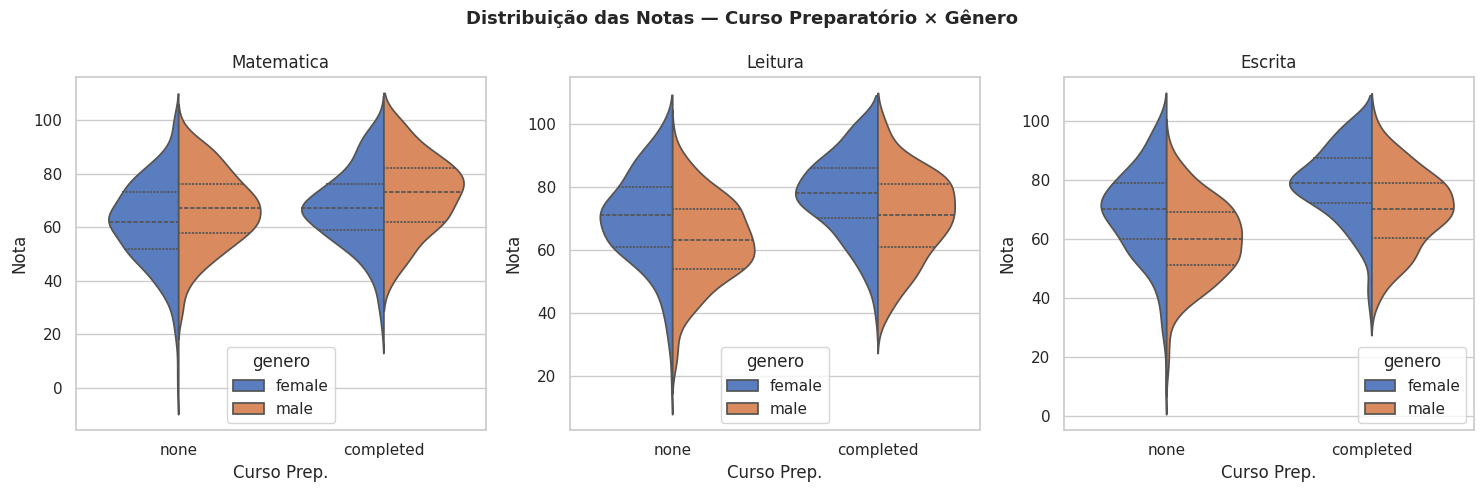

In [30]:
# Impacto combinado: curso prep + gênero nas notas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, cols3):
    sns.violinplot(data=df, x='curso_preparatorio', y=col, hue='genero',
                   split=True, palette='muted', ax=ax, inner='quart')
    ax.set_title(col.replace('nota_', '').capitalize())
    ax.set_xlabel('Curso Prep.')
    ax.set_ylabel('Nota')

plt.suptitle('Distribuição das Notas — Curso Preparatório × Gênero', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

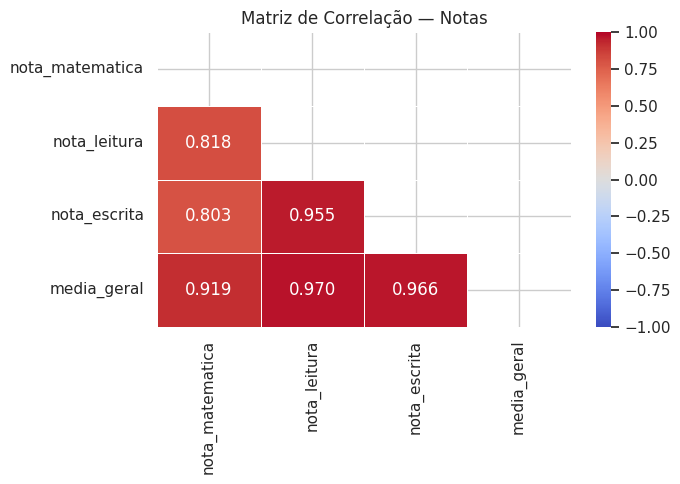

In [31]:
# Heatmap de correlação entre as notas
corr = df[['nota_matematica', 'nota_leitura', 'nota_escrita', 'media_geral']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlação — Notas', fontsize=12)
plt.tight_layout()
plt.show()

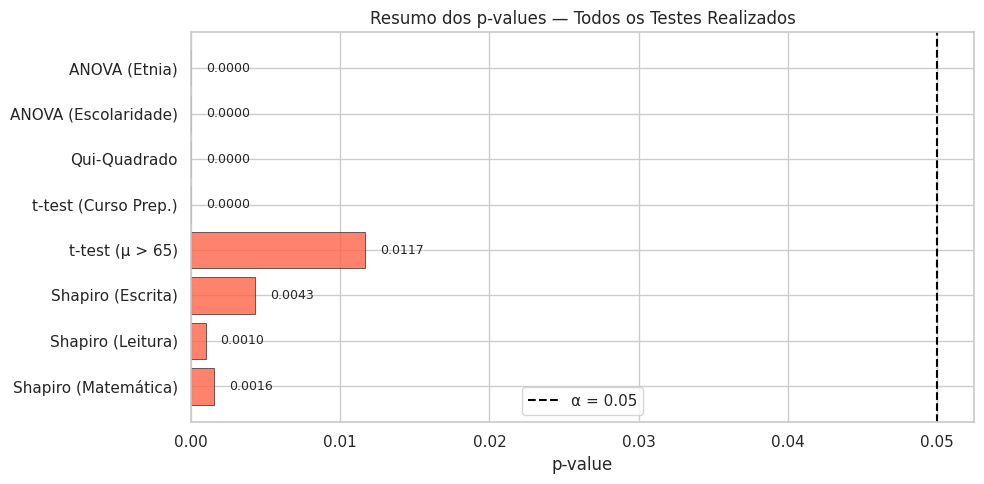

🔴 Vermelho = p < 0.05 → Rejeitamos H₀ | 🔵 Azul = p ≥ 0.05 → Não rejeitamos H₀


In [32]:
# Resumo visual dos p-values de todos os testes
testes = {
    'Shapiro (Matemática)': shapiro(df['nota_matematica'].sample(200, random_state=42))[1],
    'Shapiro (Leitura)': shapiro(df['nota_leitura'].sample(200, random_state=42))[1],
    'Shapiro (Escrita)': shapiro(df['nota_escrita'].sample(200, random_state=42))[1],
    't-test (μ > 65)': ttest_1samp(df['nota_matematica'], 65)[1] / 2,
    't-test (Curso Prep.)': ttest_ind(grupo_com, grupo_sem)[1],
    'Qui-Quadrado': p_chi,
    'ANOVA (Escolaridade)': p_anova,
    'ANOVA (Etnia)': p2_anova,
}

fig, ax = plt.subplots(figsize=(10, 5))
nomes = list(testes.keys())
pvals = list(testes.values())
cores_p = ['tomato' if p < 0.05 else 'steelblue' for p in pvals]

bars = ax.barh(nomes, pvals, color=cores_p, edgecolor='black', linewidth=0.5, alpha=0.8)
ax.axvline(0.05, color='black', linestyle='--', label='α = 0.05')
ax.set_xlabel('p-value')
ax.set_title('Resumo dos p-values — Todos os Testes Realizados')
ax.legend()
for bar, p in zip(bars, pvals):
    ax.text(p + 0.001, bar.get_y() + bar.get_height()/2, f'{p:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('🔴 Vermelho = p < 0.05 → Rejeitamos H₀ | 🔵 Azul = p ≥ 0.05 → Não rejeitamos H₀')

---
# 🏁 CONCLUSÃO FINAL

## Principais Achados da Análise Estatística

### 📐 Parte 4 — Distribuição Normal
As notas dos alunos apresentam distribuição **aproximadamente normal**, validada pelo teste de Shapiro-Wilk e pelos Q-Q plots. Isso confirma que as técnicas paramétricas utilizadas nas partes seguintes são estatisticamente adequadas.

### 📏 Parte 5 — Intervalos de Confiança
Com 95% de confiança, as médias populacionais de cada disciplina podem ser estimadas com pequenas margens de erro (< 1,5 pontos). Notas de leitura e escrita tendem a ser ligeiramente superiores à de matemática. Aproximadamente **metade dos alunos** completou o curso preparatório.

### 🧪 Parte 6 — Testes de Hipótese
- O **curso preparatório** tem impacto **estatisticamente significativo** na média geral dos alunos (p < 0.05).
- A distribuição **binomial** modela bem a probabilidade de encontrar alunos com curso prep. em uma turma.
- A distribuição de **Poisson** permite estimar a frequência de alunos de alto desempenho por turma.

### 📊 Parte 7 — Qui-Quadrado, ANOVA e Métricas
- O **Qui-Quadrado** confirmou associação entre curso preparatório e desempenho em matemática.
- A **ANOVA** revelou diferenças significativas entre grupos de escolaridade dos pais e entre etnias.
- O **coeficiente de variação** mostra que matemática tem a maior variabilidade relativa, indicando maior disparidade entre os alunos nessa disciplina.
- As notas de leitura e escrita possuem **alta correlação** (r > 0.95), sugerindo competências linguísticas integradas.

## 💡 Recomendações
1. Ampliar o acesso ao **curso preparatório**, dado seu impacto comprovado no desempenho.
2. Investigar as causas da **variabilidade em matemática** e oferecer suporte direcionado.
3. Considerar o contexto socioeconômico (almoço standard vs. free/reduced) como fator de intervenção prioritária.
4. Políticas de equidade devem considerar o nível de escolaridade dos pais, que mostrou relação com o desempenho.